In [1]:
image_set = "utzap"
text_set = "nemotron"
mode = "val"

In [2]:
import pickle
import re
import random
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
import tempfile
from vertexai.generative_models import GenerativeModel
from vertexai.generative_models import Image as VertexImage
import json
import numpy as np

In [3]:

def compare_images(persona_text: str, pil_images: list) -> list:
    """
    Accepts a persona text and two PIL images.
    Determines which image fits the persona better.
    """

    model = GenerativeModel("gemini-2.0-flash")


    from google.api_core.exceptions import InternalServerError
    import time
    def safe_generate(prompt, image_objs, retries=10, delay=3):
        for attempt in range(retries):
            try:
                response = model.generate_content([prompt] + image_objs, generation_config={"temperature": 0.0})
                return response
            except InternalServerError as e:
                print(f"[Retry {attempt+1}/{retries}] Gemini 500 error: {e}")
                time.sleep(delay * (2 ** attempt))  # exponential backoff
            except Exception as e:
                print(f"[Retry {attempt+1}/{retries}] Unexpected error: {e}")
                time.sleep(delay * (2 ** attempt))  # exponential backoff
        return 0 #None


    prompt = f"""
    You are evaluating how well the two products in the images matches a given customer persona.

    Persona:
    {persona_text}

    You will be shown two product images.

    Please output 0 for the first image if it fits the persona better, 1 for the second image if it fits the persona better.

    Do NOT include any explanation or additional text.
    """
    try:
        # Save all images to temporary files, load into Image objects
        image_objs = []
        temp_files = []
        try:
            for pil_image in pil_images:
                tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
                pil_image.save(tmp.name)
                temp_files.append(tmp.name)
                image_obj = VertexImage.load_from_file(tmp.name)
                image_objs.append(image_obj)
                tmp.close()

            # Generate response with prompt + all images
            response = safe_generate(prompt, image_objs)

            # You might get a single combined response — if you want per image,
            # you could send one call per image in a loop instead.

        finally:
            # Clean up temp files
            for f in temp_files:
                try:
                    os.remove(f)
                except Exception:
                    pass

        match = re.search(r'\d+', response.text)
        if match:
            cleaned_response = int(match.group())
        else:
            cleaned_response = 0
        return cleaned_response
    except Exception as e:
        print(f"Error generating response: {e}")
        return 0 #"Error generating response"

In [4]:
if mode == "test":
    with open(f'../data_preparation/{image_set}/images_test.pkl', 'rb') as f:
        sampled_images = pickle.load(f)
    with open(f'../data_preparation/{text_set}/test_personas.json', 'r') as f:
        sampled_personas = json.load(f)[:50]
elif mode == "val": 
    with open(f'../data_preparation/{image_set}/images_val.pkl', 'rb') as f:
        sampled_images = pickle.load(f)
    with open(f'../data_preparation/{text_set}/validation_personas.json', 'r') as f:
        sampled_personas = json.load(f)[:50]

In [ ]:
import json
import os

# Where to save the results
results_file = f"{image_set + "+" + text_set}/{mode}_indices.json"

# Load existing results if file exists
if os.path.exists(results_file):
    with open(results_file, "r") as f:
        final_indices = json.load(f)
else:
    final_indices = []

start_index = len(final_indices)  # Resume from where we left off

for i, persona in enumerate(tqdm(sampled_personas[start_index:], desc="Personas", initial=start_index, total=len(sampled_personas))):
    previous_indices = list(range(len(sampled_images)))
    while len(previous_indices) > 1:
        new_indices = []
        pairs = []

        # Prepare pairs of indices
        for i in range(0, len(previous_indices), 2):
            if i + 1 < len(previous_indices):
                pairs.append((previous_indices[i], previous_indices[i + 1]))
            else:
                new_indices.append(previous_indices[i])

        # Parallel compare pairs
        with ThreadPoolExecutor(max_workers=8) as executor:
            futures = {
                executor.submit(compare_images, persona, [sampled_images[pair[0]], sampled_images[pair[1]]]): pair
                for pair in pairs
            }

            for future in tqdm(as_completed(futures), total=len(futures), desc="Comparisons", leave=False):
                pair = futures[future]
                try:
                    response = future.result()
                    if response == 0:
                        new_indices.append(pair[0])
                    else:
                        new_indices.append(pair[1])
                except Exception as e:
                    print(f"Error comparing images {pair}: {e}")
                    # Choose randomly or skip
                    new_indices.append(random.choice(pair))

        random.shuffle(new_indices)
        previous_indices = new_indices

    final_indices.append(previous_indices[0])

    # Save current progress
    with open(results_file, "w") as f:
        json.dump(final_indices, f)

Personas:   0%|          | 0/50 [00:00<?, ?it/s]

Comparisons:   0%|          | 0/2048 [00:00<?, ?it/s]

[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refe

Comparisons:   0%|          | 0/1024 [00:00<?, ?it/s]

[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refe

...

Comparisons:   0%|          | 0/1 [00:00<?, ?it/s]

Comparisons:   0%|          | 0/2048 [00:00<?, ?it/s]

[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refe

Comparisons:   0%|          | 0/1024 [00:00<?, ?it/s]

[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
[Retry 1/10] Unexpected error: 429 Resource exhausted. Please try again later. Please refe

In [ ]:
import json
with open(f"{image_set + "+" + text_set}/{mode}_indices.json", "r") as f:
    final_indices = json.load(f)

In [ ]:
len(final_indices)

50

44
an old-time fan of the Command & Conquer video game series


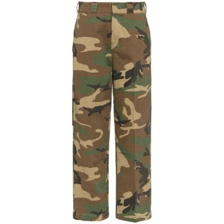

In [ ]:
n = random.randint(0, len(final_indices) - 1)
print(n)
print(sampled_personas[n])
sampled_images[final_indices[n]]

In [ ]:
# import json
# import os

# if mode == "test":
#     # Where to save the results
#     results_file = f"{image_set + "+" + text_set}/rerun_rank.json"

#     # Load existing results if file exists
#     if os.path.exists(results_file):
#         with open(results_file, "r") as f:
#             rerun_ranks = json.load(f)
#     else:
#         rerun_ranks = []

#     start_index = len(rerun_ranks)  # Resume from where we left off
#     finish_index = len(final_indices)  # Total number of personas to process

#     for i, persona in enumerate(tqdm(sampled_personas[start_index:finish_index], desc="Personas", initial=start_index, total=finish_index)):
#         previous_indices = list(range(len(sampled_images)))
#         skip = False
#         while len(previous_indices) > 1:
#             new_indices = []
#             pairs = []

#             # Prepare pairs of indices
#             for j in range(0, len(previous_indices), 2):
#                 if j + 1 < len(previous_indices):
#                     pairs.append((previous_indices[j], previous_indices[j + 1]))
#                 else:
#                     new_indices.append(previous_indices[j])


#             if final_indices[i] not in previous_indices:
#                 rerun_ranks.append(int(np.log2(len(previous_indices)*2)))
#                 skip = True
#                 break

#             # Parallel compare pairs
#             with ThreadPoolExecutor(max_workers=8) as executor:
#                 futures = {
#                     executor.submit(compare_images, persona, [sampled_images[pair[0]], sampled_images[pair[1]]]): pair
#                     for pair in pairs
#                 }

#                 for future in tqdm(as_completed(futures), total=len(futures), desc="Comparisons", leave=False):
#                     pair = futures[future]
#                     try:
#                         response = future.result()
#                         if response == 0:
#                             new_indices.append(pair[0])
#                         else:
#                             new_indices.append(pair[1])
#                     except Exception as e:
#                         print(f"Error comparing images {pair}: {e}")
#                         # Choose randomly or skip
#                         new_indices.append(random.choice(pair))

#             random.shuffle(new_indices)
#             previous_indices = new_indices
#         if not skip:
#             if final_indices[i] not in previous_indices:
#                 rerun_ranks.append(1)
#             else:
#                 rerun_ranks.append(0)

#         # Save current progress
#         with open(results_file, "w") as f:
#             json.dump(rerun_ranks, f)